# Machine Learning for Thermal Engineers
## Lesson 4: Multivariable Regression

Author: Srikantan Natarajan

# 1. Problem Motivation

In the earlier lessons, we modeled a simple relationship between one input and one output:

$$
y = wx + b
$$

For example:

Ambient Temperature $\rightarrow$ Compressor Power

But real thermal systems are influenced by multiple variables at the same time.

For a simplified HVAC cooling scenario, compressor power may be influenced by:

- Ambient temperature
- Solar load
- Humidity
- Cabin air temperature
- Set temperature
- Blower speed

A single-variable model cannot capture all of these effects.

This motivates **multivariable regression**, where multiple input features are used to predict a single output.

# 2. Mathematical Intuition

In multivariable regression, the output is modeled as a weighted sum of multiple inputs:

$$
y = w_1x_1 + w_2x_2 + w_3x_3 + \cdots + b
$$

Where:

- $x_1, x_2, x_3, \ldots$ are input features
- $w_1, w_2, w_3, \ldots$ are learned weights
- $b$ is the intercept

For a simplified HVAC example, we may write:

$$
CompressorPower =
w_1(\mathrm{AmbientTemp}) +
w_2(\mathrm{SolarLoad}) +
w_3(\mathrm{Humidity}) +
w_4(\mathrm{CabinTemp}) +
w_5(\mathrm{SetTemp}) +
w_6(\mathrm{BlowerSpeed}) + b
$$

Each weight tells us how strongly that feature influences the predicted compressor power.

# 3. Engineering Analogy

This structure is very similar to how thermal engineers often think about weighted relationships.

For example, in HVAC calibration or comfort modeling, engineers may combine multiple variables to create an equivalent temperature or load-related term.

The key difference is:

- In traditional engineering calibration, the weights are selected manually.
- In machine learning, the weights are learned automatically from data.

So multivariable regression can be thought of as a form of **data-driven parameter estimation** or **automatic calibration**.

# 4. Synthetic Dataset

To keep this notebook educational and non-proprietary, we will generate a **synthetic HVAC-style dataset**.

The synthetic dataset will include:

- Ambient temperature
- Solar load
- Humidity
- Cabin air temperature
- Set temperature
- Blower speed

And we will create a physically reasonable compressor power relationship with some random noise added.

This keeps the example realistic while avoiding any real vehicle test data or confidential calibration values.

# 5. Python Implementation

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)

n_samples = 200

# Generate synthetic HVAC-style input features
ambient_temp = np.random.uniform(25, 45, n_samples)         # deg C
solar_load = np.random.uniform(200, 1000, n_samples)        # W/m^2
humidity = np.random.uniform(30, 80, n_samples)             # %
cabin_temp = np.random.uniform(22, 45, n_samples)           # deg C
set_temp = np.random.uniform(18, 24, n_samples)             # deg C
blower_speed = np.random.uniform(5, 10, n_samples)          # arbitrary blower scale

# Create a synthetic cooling-load-like relationship
# This is only for educational purposes
noise = np.random.normal(0, 0.25, n_samples)

compressor_power = (
    0.05 * ambient_temp +
    0.0015 * solar_load +
    0.015 * humidity +
    0.12 * cabin_temp -
    0.10 * set_temp +
    0.08 * blower_speed +
    noise
)

# Assemble into a DataFrame
df = pd.DataFrame({
    "AmbientTemp_C": ambient_temp,
    "SolarLoad_Wm2": solar_load,
    "Humidity_pct": humidity,
    "CabinTemp_C": cabin_temp,
    "SetTemp_C": set_temp,
    "BlowerSpeed": blower_speed,
    "CompressorPower_kW": compressor_power
})

df.head()

In [ ]:
feature_names = [
    "AmbientTemp_C",
    "SolarLoad_Wm2",
    "Humidity_pct",
    "CabinTemp_C",
    "SetTemp_C",
    "BlowerSpeed"
]

X = df[feature_names]
y = df["CompressorPower_kW"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

# 6. Feature Matrix and Target

In machine learning notation:

- $X$ = feature matrix
- $Y$ = target variable

Here, the features are the HVAC-related input variables, and the target is compressor power.

# 7. Train the Multivariable Regression Model

We now fit a linear regression model to learn the relationship between the input features and compressor power.

In [ ]:
model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

print("Intercept:", round(model.intercept_, 4))
print("\nLearned coefficients:")
for feature, coef in zip(feature_names, model.coef_):
    print(f"{feature}: {coef:.4f}")

# 8. Model Performance

To evaluate the fit, we compute:

- Mean Squared Error (MSE)
- $R^2$ score

Since this dataset was synthetically generated from a linear relationship, we expect a very strong fit.

In [ ]:
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("Mean Squared Error (MSE):", round(mse, 4))
print("R^2 Score:", round(r2, 4))

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(y, y_pred)
plt.xlabel("Actual Compressor Power (kW)")
plt.ylabel("Predicted Compressor Power (kW)")
plt.title("Actual vs Predicted Compressor Power")
plt.grid(True)
plt.show()

# 9. Visualization

Intercept: -0.3138

Learned coefficients:
AmbientTemp_C: 0.0529
SolarLoad_Wm2: 0.0015
Humidity_pct: 0.0138
CabinTemp_C: 0.1192
SetTemp_C: -0.0834
BlowerSpeed: 0.0780

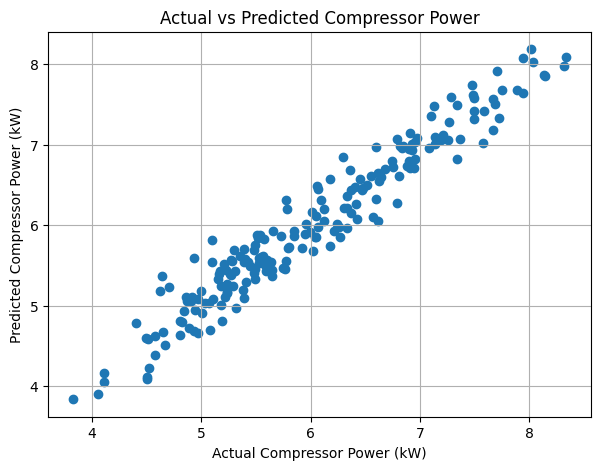

The actual vs predicted plot helps us see how well the model learned the relationship.

If the model is performing well, the predicted values should closely follow the actual values.

Because this dataset was generated from a linear equation with moderate noise, the regression model shows a strong fit.

# 10. Interpreting the Coefficients

One useful aspect of multivariable regression is that it allows us to inspect the learned feature weights.

For example:

- A larger positive coefficient means that increasing that variable tends to increase compressor power.
- A negative coefficient means that increasing that variable tends to reduce compressor power.
- A coefficient close to zero means that the variable has relatively little influence in the learned model.

In this synthetic example:

- Higher ambient temperature should increase cooling demand
- Higher solar load should increase cooling demand
- Higher cabin temperature should increase cooling demand
- Lower set temperature should increase cooling demand
- Higher blower speed may increase the effective cooling demand seen by the system

# 11. Key Takeaways

- Multivariable regression extends linear regression to multiple input features.
- The model learns a weighted combination of several variables.
- This is very similar to engineering-style weighted formulations, except the weights are learned from data.
- Inspecting coefficients provides useful physical intuition about the modeled system.
- Domain expertise is extremely valuable when selecting meaningful features.

# 12. Try It Yourself

Experiment with the notebook by changing the synthetic relationship or the feature list.

Ideas to explore:

1. Increase the amount of noise and see how model performance changes.
2. Remove one feature and observe whether the coefficients or fit quality change.
3. Add a new feature such as seat temperature or interior trim temperature.
4. Change the set temperature range and observe its influence on compressor power.